Link Dashboard : https://public.tableau.com/app/profile/hazna.ardeva/viz/DashboardMIlestone2/SingaporeApartmentResaleMarketAnalysisDashboard?publish=yes

# Perkenalan


Milestone 2

Nama  : Hazna Dhifa Putri Ardeva

Batch : CODA-RMT-014

Milestones ini dibuat untuk mengerjakan final project data analyst dengan output dashboard



# Identifikasi Masalah

Dataset: https://www.kaggle.com/datasets/teyang/singapore-hdb-flat-resale-prices-19902020
(Fokus analisis: Hanya data 4 tahun terakhir 2017–2020)

- Latar Belakang:

  Perusahaan Prime Property merupakan perusahaan developer properti menengah yang fokus pada pengembangan apartemen terjangkau untuk kelas menengah bawah. Perusahaan ini menghadapi tantangan dalam menentukan strategi penjualan, harga jual yang kompetitif, karakteristik apartemen, dan lokasi pengembangan yang tepat untuk project baru mereka. Untuk mengatasi hal ini, perusahaan menggunakan data resale flat HDB Singapore selama 4 tahun terakhir (2017-2020) sebagai benchmark untuk menetapkan strategi penjualan. Perusahaan membutuhkan data karakteristik apartemen yang diminati pasar dan wilayah pengembangan yang tepat untuk strategi penjualan apartemen dengan harga kompetitif

- Tujuan:

  Memberikan rekomendasi harga jual yang kompetitif, karakteristik dan wilayah penjualan apartemen yang tepat dalam perencanaan project baru sesuai tren pasar

- Problem Statement:

  Mengetahui estimasi harga resale terhadap karakteristik apartemen yang kompetitif di wilayah dengan kontribusi transaksi yang tinggi

Metode SMART
  - Specific: Membuat project baru pengembangan apartemen dengan mengidentifikasi tren pasar penjualan apartemen 4 tahun terakhir, faktor yang mempengaruhi harga, wilayah yang memberikan kontribusi transaksi yang besar, dan estimasi harga penjualan apartemen
  - Measurable: Meningkatkan penjualan apartemen perushaan hingga 80%
  - Achievable: Berdasarkan optimalisasi strategi penjualan yang terencana, potensi apartemen terjual meningkat menjadi 80%
  - Relevant: Memfokuskan strategi penjualan dengan memperhatikan harga, karakteristik apartemen, dan wilayah berdasarkan minat pasar sangat penting untuk bisa bersaing dengan kompetitor
  - Time-bound: Strategi ditetapkan untuk 6 bulan ke depan

# Data Loading

In [1]:
# Import semua library yang akan digunakan
import pandas as pd
from scipy import stats
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import matplotlib.ticker as mtick


In [2]:
# Upload dan melihat dataset
df = pd.read_csv('/content/resale-flat-prices-based-on-registration-date-from-jan-2017-onwards.csv')
df

,month,town,flat_type,block,street_name,storey_range,floor_area_sqm,flat_model,lease_commence_date,remaining_lease,resale_price
0,2017-01,ANG MO KIO,2 ROOM,406,ANG MO KIO AVE 10,10 TO 12,44.0,Improved,1979,61 years 04 months,232000.0
1,2017-01,ANG MO KIO,3 ROOM,108,ANG MO KIO AVE 4,01 TO 03,67.0,New Generation,1978,60 years 07 months,250000.0
2,2017-01,ANG MO KIO,3 ROOM,602,ANG MO KIO AVE 5,01 TO 03,67.0,New Generation,1980,62 years 05 months,262000.0
3,2017-01,ANG MO KIO,3 ROOM,465,ANG MO KIO AVE 10,04 TO 06,68.0,New Generation,1980,62 years 01 month,265000.0
4,2017-01,ANG MO KIO,3 ROOM,601,ANG MO KIO AVE 5,01 TO 03,67.0,New Generation,1980,62 years 05 months,265000.0
...,...,...,...,...,...,...,...,...,...,...,...
80369,2020-09,YISHUN,5 ROOM,716,YISHUN ST 71,07 TO 09,131.0,Improved,1987,66 years 03 months,440000.0
80370,2020-09,YISHUN,5 ROOM,760,YISHUN ST 72,07 TO 09,122.0,Improved,1987,65 years 06 months,458000.0
80371,2020-09,YISHUN,5 ROOM,835,YISHUN ST 81,04 TO 06,122.0,Improved,1987,66 years 04 months,490000.0
80372,2020-09,YISHUN,EXECUTIVE,791,YISHUN AVE 2,04 TO 06,146.0,Maisonette,1987,66 years 03 months,558000.0


In [3]:
# Cek informasi dan struktur dataset
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 80374 entries, 0 to 80373
Data columns (total 11 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   month                80374 non-null  object 
 1   town                 80374 non-null  object 
 2   flat_type            80374 non-null  object 
 3   block                80374 non-null  object 
 4   street_name          80374 non-null  object 
 5   storey_range         80374 non-null  object 
 6   floor_area_sqm       80374 non-null  float64
 7   flat_model           80374 non-null  object 
 8   lease_commence_date  80374 non-null  int64  
 9   remaining_lease      80374 non-null  object 
 10  resale_price         80374 non-null  float64
dtypes: float64(2), int64(1), object(8)
memory usage: 6.7+ MB


Dataset merupakan data transaksi penjualan kembali apartemen / perumahan bekas milik Housing Development Board (HDB) di Singapore. Dataset terdiri dari 80.374 rows dan 11 column. Informasi terkait data description dapat dilihat sebagai berikut:

| Column | Description
| :--- | :---
| month | Tanggal transaksi (datetime)
| town | Kota / wilayah apartemen (str)
| flat_type | Tipe apartemen (str)
| block | No alamat apartemen (str)
| street_name | Alamat apartemen (str)
| storey_range | Rentang lantai tempat apartemen berada (str)
| floor_area_sqm | Luas area apartemen (float)
| flat_model | Model apartemen (str)
| lease_commence_date | Tahun mulai sewa (datetime)
| remaining_lease | Sisa waktu sewa (str)
| resale_price | Harga jual ulang (float)


# Data Cleaning

## Handling Duplicate

In [4]:
# Pengecekan duplikasi data
df.duplicated().sum()

np.int64(210)

In [5]:
# Menghapus data duplikat dan menyimpannya dalam dataframe
df.drop_duplicates(inplace=True)

# Mengecek kelmbali duplikasi data
df.duplicated().sum()

np.int64(0)

In [6]:
# Melihat struktur dan informasi dataset setelah handling duplicate
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 80164 entries, 0 to 80373
Data columns (total 11 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   month                80164 non-null  object 
 1   town                 80164 non-null  object 
 2   flat_type            80164 non-null  object 
 3   block                80164 non-null  object 
 4   street_name          80164 non-null  object 
 5   storey_range         80164 non-null  object 
 6   floor_area_sqm       80164 non-null  float64
 7   flat_model           80164 non-null  object 
 8   lease_commence_date  80164 non-null  int64  
 9   remaining_lease      80164 non-null  object 
 10  resale_price         80164 non-null  float64
dtypes: float64(2), int64(1), object(8)
memory usage: 7.3+ MB


Data terdiri dari 80.164 rows dan 11 column setelah handling duplikat dilakukan


## Converting Data Type

In [7]:
# Converting data type
df['month'] = pd.to_datetime(df['month'])

df['lease_commence_date'] = pd.to_datetime(df['lease_commence_date'].astype(str) + '-01-01')
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 80164 entries, 0 to 80373
Data columns (total 11 columns):
 #   Column               Non-Null Count  Dtype         
---  ------               --------------  -----         
 0   month                80164 non-null  datetime64[ns]
 1   town                 80164 non-null  object        
 2   flat_type            80164 non-null  object        
 3   block                80164 non-null  object        
 4   street_name          80164 non-null  object        
 5   storey_range         80164 non-null  object        
 6   floor_area_sqm       80164 non-null  float64       
 7   flat_model           80164 non-null  object        
 8   lease_commence_date  80164 non-null  datetime64[ns]
 9   remaining_lease      80164 non-null  object        
 10  resale_price         80164 non-null  float64       
dtypes: datetime64[ns](2), float64(2), object(7)
memory usage: 7.3+ MB


In [8]:
# Membuat kolom usia bangunan
df['building_age'] = (pd.to_datetime('2020-09-30') - df['lease_commence_date']).dt.days / 365.25
df['building_age'] = df['building_age'].round()
df['building_age'] = df['building_age'].astype(int)
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 80164 entries, 0 to 80373
Data columns (total 12 columns):
 #   Column               Non-Null Count  Dtype         
---  ------               --------------  -----         
 0   month                80164 non-null  datetime64[ns]
 1   town                 80164 non-null  object        
 2   flat_type            80164 non-null  object        
 3   block                80164 non-null  object        
 4   street_name          80164 non-null  object        
 5   storey_range         80164 non-null  object        
 6   floor_area_sqm       80164 non-null  float64       
 7   flat_model           80164 non-null  object        
 8   lease_commence_date  80164 non-null  datetime64[ns]
 9   remaining_lease      80164 non-null  object        
 10  resale_price         80164 non-null  float64       
 11  building_age         80164 non-null  int64         
dtypes: datetime64[ns](2), float64(2), int64(1), object(7)
memory usage: 8.0+ MB


Converting data type dilakukan dengan mengubah tipe data pada kolom month dan lease_commence_date menjadi datetime, dan membuat kolom baru untuk prepare data untuk analisis usia bangunan

Hasil cleaning yang dilakukan pada dataset yaitu:
- Handling duplicate
- Converting data type
- Add new column

# Analisis dan Perhitungan

#### 1. Apa tren harga resale dan transaksi penjualan apartemen per tahun?





In [9]:
# Melakukan grouping harga resale per tahun dari tahun 2017-2020
year_avg_price = df.groupby(df['month'].dt.year)['resale_price'].mean().reset_index()
year_avg_price.columns = ['year', 'average_resale_price']
year_avg_price['year'] = year_avg_price['year'].astype(str)

# Melihat hasil tren harga tahunan
year_avg_price

,year,average_resale_price
0,2017,443743.443497
1,2018,441310.438730
2,2019,432180.067468
3,2020,440775.434502


Text(0, 0.5, 'Rata-rata Harga Resale (SGD)')

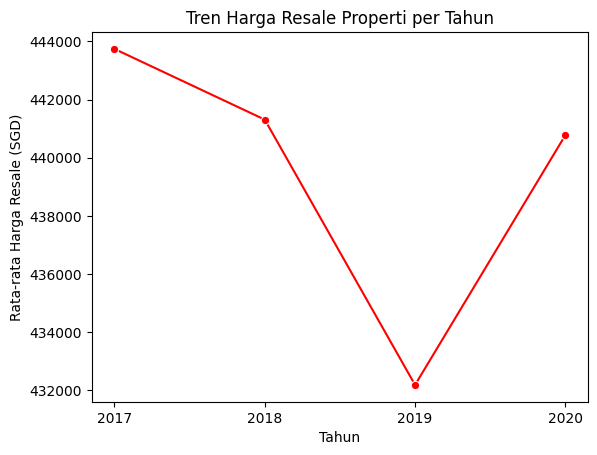

In [10]:
# Melakukan visualisasi terhadap tren harga resale properti dengan menggunakan matplotlib dan seaborn
plt.figure()
sns.lineplot(data=year_avg_price, x='year', y='average_resale_price', color='red', marker='o')
plt.title('Tren Harga Resale Properti per Tahun')
plt.xlabel('Tahun')
plt.ylabel('Rata-rata Harga Resale (SGD)')

- Tren harga tahunan resale apartemen menunjukkan adanya penurunan dari tahun 2018 ke tahun 2019, dan kemudian terjadi peningkatan yang signifikan pada tahun 2020
- Harga resale tertinggi terdapat pada tahun 2017, dimana rata-rata harga penjualan apartemen yaitu sebesar 443.743 SGD, dan terendah pada tahun 2019 yaitu sebesar 432.180 SGD

In [11]:
# Melakukan grouping total transaksi per tahun dari tahun 2017-2020
total_transactions = df.groupby(df['month'].dt.year)['resale_price'].count().reset_index()
total_transactions = total_transactions.rename(columns={'resale_price': 'total_transactions'})
total_transactions = total_transactions.rename(columns={'month': 'year'})
total_transactions

,year,total_transactions
0,2017,20337
1,2018,21552
2,2019,22168
3,2020,16107


Text(0, 0.5, 'Total Transaksi')

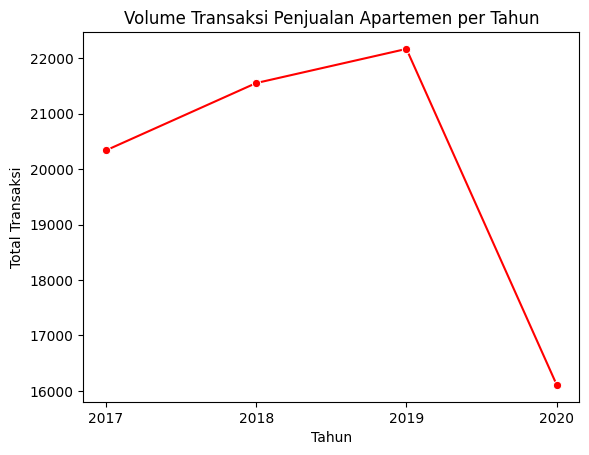

In [12]:
# Melakukan visualisasi terhadap tren harga resale properti dengan menggunakan matplotlib dan seaborn
plt.figure()
sns.lineplot(data=total_transactions, x='year', y='total_transactions', color='red', marker='o')
plt.xticks(total_transactions['year'].unique(), rotation=0)
plt.title('Volume Transaksi Penjualan Apartemen per Tahun')
plt.xlabel('Tahun')
plt.ylabel('Total Transaksi')

- Visualisasi tren volume transaksi apartemen dalam kurun waktu 4 tahun terakhir (2017-2020) menunjukkan penjualan apartemen mengalami peningkatan tiap tahunnya, namun terjadi penurunan yang signifikan pada tahun 2020
- Total transaksi tertinggi terjadi pada tahun 2019, dimana terdapat sebanyak 22.168 transaksi, dan terendah terjadi pada tahun 2020, yaitu hanya sebanyak 16.107 transaksi



#### 2. Wilayah (town) mana yang memiliki harga resale dan aktivitas transaksi yang tinggi?

In [13]:
# Menghitung rata-rata harga resale dan total transaksi per wilayah
town_price = df.groupby('town')['resale_price'].agg(['mean', 'median', 'count']).reset_index()
town_price = town_price.sort_values('mean', ascending=False)

# Melihat hasil rata-rata harga tertinggi di 5 wilayah teratas
print("Top 5 wilayah berdasarkan rata-rata harga:")
print(town_price.head(5))

# Melihat hasil jumlah transaksi tertinggi di 5 wilayah teratas
print("\nTop 5 wilayah berdasarkan total transaksi:")
print(town_price.sort_values('count', ascending=False).head(5))

Top 5 wilayah berdasarkan rata-rata harga:
            town           mean    median  count
6    BUKIT TIMAH  711565.245455  713444.0    220
2         BISHAN  641819.391503  620000.0   1530
7   CENTRAL AREA  617941.321101  500000.0    654
4    BUKIT MERAH  563019.009028  582000.0   3088
18    QUEENSTOWN  558765.994745  560000.0   2139

Top 5 wilayah berdasarkan total transaksi:
           town           mean    median  count
20     SENGKANG  437424.743011  428000.0   6383
24    WOODLANDS  378875.389063  365000.0   6009
13  JURONG WEST  390592.456068  385000.0   5972
25       YISHUN  363586.507903  340000.0   5631
22     TAMPINES  474751.767669  450000.0   5221


Text(0, 0.5, 'Town')

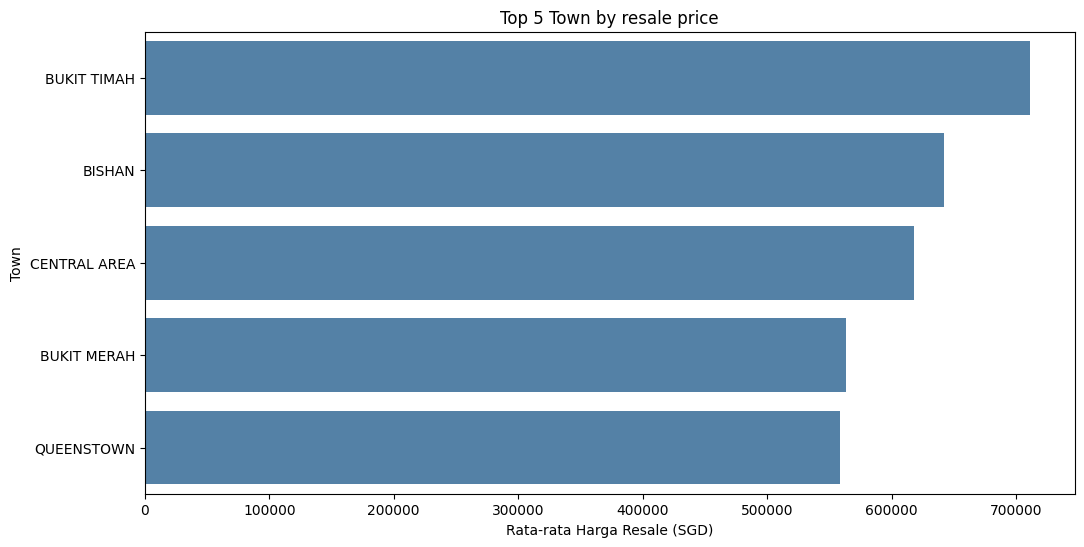

In [14]:
# Membuat visualisasi terhadap top 5 town / wilayah berdasarkan rata-rata harga
top5_price = town_price.head(5)

plt.figure(figsize=(12, 6))
sns.barplot(data=top5_price, x='mean', y='town', color='Steelblue')
plt.title('Top 5 Town by resale price')
plt.xlabel('Rata-rata Harga Resale (SGD)')
plt.ylabel('Town')


- Hasil analisis dan visualisasi menunjukkan town/wilayah dengan harga resale tertinggi yaitu pada wilayah Bukit Timah, dengan rata-rata harga sebesar 711.565 SGD

Text(0, 0.5, 'Town')

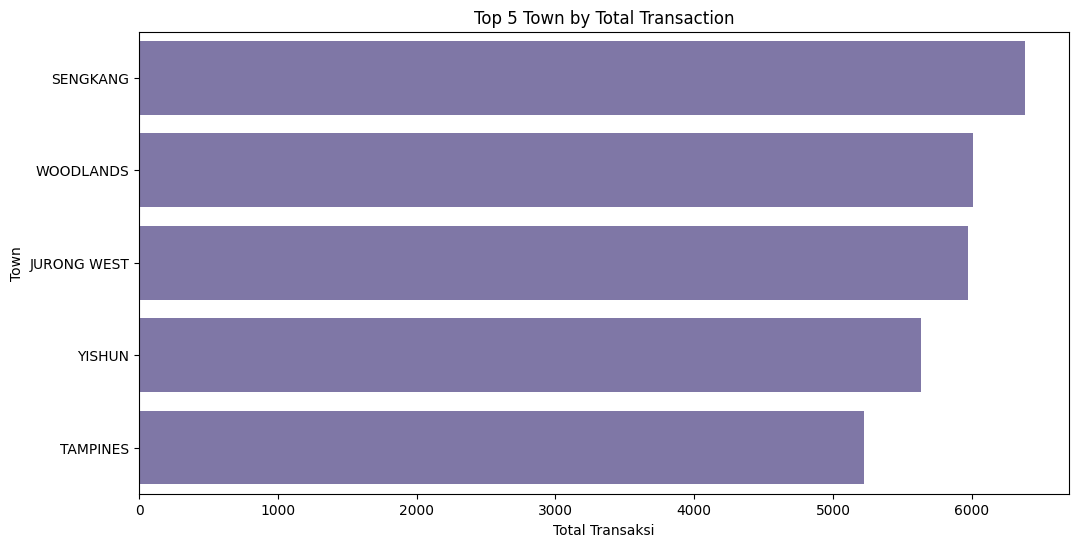

In [15]:
# Membuat visualisasi terhadap top 5 town / wilayah berdasarkan total transaksi
top5_transaction = town_price.sort_values('count', ascending=False).head(5)

plt.figure(figsize=(12, 6))
sns.barplot(data=top5_transaction, x='count', y='town', color='#7A6FAE')
plt.title('Top 5 Town by Total Transaction')
plt.xlabel('Total Transaksi')
plt.ylabel('Town')

- Hasil analisis dan visualisasi menunjukkan aktivitas transaksi tertinggi terdapat pada town / wilayah Sengkang, dimana terdapat sebanyak 6.383 transaksi
- Tinggi nya aktivitas transaksi pada town / wilayah Sengkang menandakan mayoritas customer memilih town / wilayah di Sengkang dalam membeli apartemen, sehingga penjualan apartemen pada wilayah ini memiliki potensi yang besar  
- Hasil analisis ini menunjukkan mayoritas volume transaksi yang tinggi berada pada wilayah dengan rata-rata harga resale yang tidak tergolong mahal (terjangkau), hal ini menandakan customer kebanyakan memilih membeli apartemen pada wilayah dengan harga yang terjangkau

#### 3. Apa tipe apartemen yang memiliki volume transaksi tertinggi?

In [16]:
# Melakukan grouping by flat_type untuk melihat total transaksi per type apartemen
top_tipe = df.groupby('flat_type')['town'].agg(['count']).reset_index()

# Menampilkan type apartemen tertinggi berdasarkan total transaksi
top_tipe.sort_values('count', ascending=False)

,flat_type,count
3,4 ROOM,33156
4,5 ROOM,19898
2,3 ROOM,19394
5,EXECUTIVE,6406
1,2 ROOM,1237
6,MULTI-GENERATION,37
0,1 ROOM,36


Text(0, 0.5, 'Type')

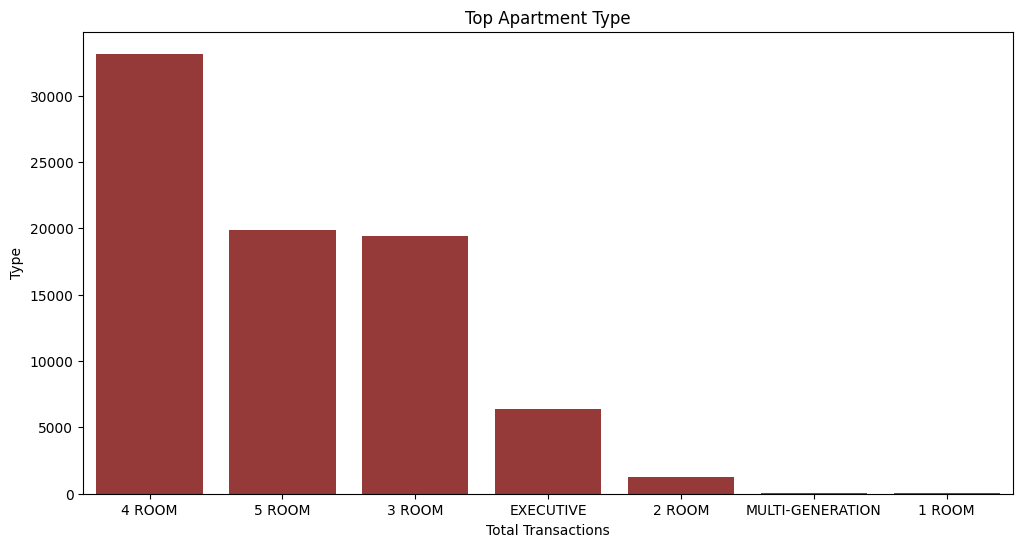

In [17]:
# Membuat visualisasi terhadap top 5 tipe apartemen berdasarkan total transaksi
top5_tipe = top_tipe.sort_values('count', ascending=False)

plt.figure(figsize=(12, 6))
sns.barplot(data=top5_tipe, x='flat_type', y='count', color='#A52A2A')
plt.title('Top Apartment Type')
plt.xlabel('Total Transactions')
plt.ylabel('Type')

- Model apartemen dengan total transaksi tertinggi yaitu tipe 4 rooms, sebanyak 33.156 transaksi
- Hasil ini menunjukkan mayoritas customer memilih apartemen dengan 4 room dalam membeli apartemen
- Hasil ini menunjukkan pemilihan apartemen dengan tipe 4 room sebagai strategi penjualan memiliki peluang yang besar

#### 4. Bagaimana pengaruh usia bangunan terhadap harga resale?

Text(0.5, 1.0, 'Building Age')

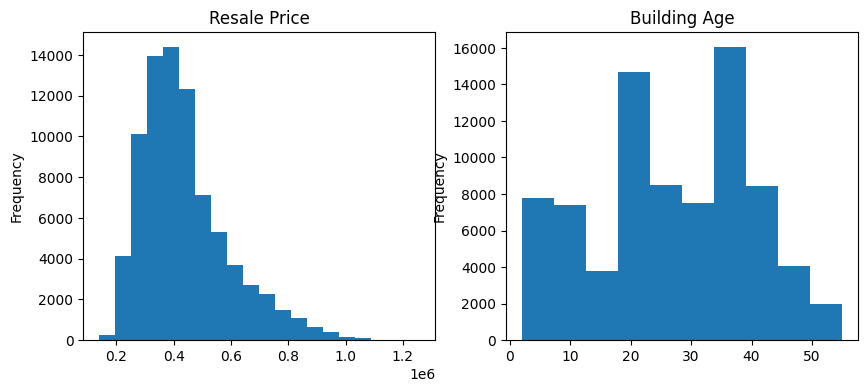

In [18]:
# Melihat visualisasi distribusi kolom building_age dan resale_price untuk menentukan teknik uji korelasi
fig, ax = plt.subplots(ncols=2,figsize=(10,4))

df['building_age'].plot(kind='hist',ax=ax[1])
df['resale_price'].plot(kind='hist',bins=20,ax=ax[0])

ax[0].set_title('Resale Price')
ax[1].set_title('Building Age')

- Distribusi data resale_price terlihat tidak normal (right skewness)
- Distribusi data building age terlihat tidak normal, namun untuk memastikan distribusi ini tidak normal, dilakukan analisis deskriptif lanjutan dengan melihat nilai mean, median, std, dan melihat nilai skewness dan kurtosis utk melihat arah skewnya

In [19]:
# Menghitung mean, median, std, skewness, dan kurtosis kolom usia bangunan
print('Kolom Usia Bangunan')
print('Rata-rata usia bangunan:', df['building_age'].mean())
print('Median usia bangunan:', df['building_age'].median())
print('Standar deviasi usia bangunan:', df['building_age'].std())
print('Skewness usia bangunan:', df['building_age'].skew())
print('Kurtosis usia bangunan:', df['building_age'].kurtosis())

Kolom Usia Bangunan
Rata-rata usia bangunan: 26.889177186767128
Median usia bangunan: 27.0
Standar deviasi usia bangunan: 12.836369012453694
Skewness usia bangunan: -0.10381002794722013
Kurtosis usia bangunan: -1.0176607141346357


- Hasil analisis deskriptif terhadap nilai skewness menunjukkan skewness < 0, yang artinya data bersifat negatif skewness, dan nilai kurtosis < 0 menunjukkan adanya outlier pada data
- karena data berdistribusi tidak normal, maka uji korelasi yang digunakan yaitu dengan metode uji **Spearman**

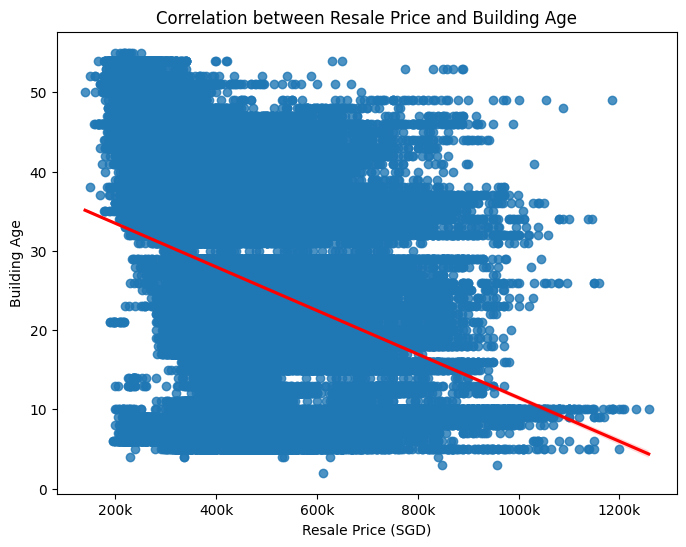

In [20]:
# Melihat korelasi antara variable usia bangunan dan harga resale apartemen dengan visualisasi scatter plot
plt.figure(figsize=(8,6))
ax = sns.regplot(data=df, x='resale_price', y='building_age',
                line_kws={'color': 'red'})

ax.xaxis.set_major_formatter(
    mtick.FuncFormatter(lambda x, _: f'{int(x/1000)}k'))

plt.xlabel('Resale Price (SGD)')
plt.ylabel('Building Age')
plt.title('Correlation between Resale Price and Building Age')
plt.show()


- Hasil analisis visualisasi menunjukkan adanya korelasi negatif antara usia bangunan dengan harga resale, dimana semakin tua usia bangunan maka semakin rendah harga resale
- Visualisasi korelasi menunjukkakn persebaran data yang bervariasi, dimana bangunan baru memiliki persebaran harga yang cukup luas, sedangkan pada bangunan dengan usia tua persebarannya lebih terpusat pada harga resale yang rendah

In [21]:
# Menghitung korelasi antara variable harga resale dan usia bangunan dengan metode Spearman
corr_rho, pval_s = stats.spearmanr(df['resale_price'], df['building_age'])

print(f"rho-correlation: {corr_rho:.2f}, p-value: {pval_s}")

rho-correlation: -0.38, p-value: 0.0


- Hasil analisis korelasi menunjukkan p-value < 0.5%, yang artinya usia bangunan yang berbeda memengaruhi harga resale
- Hasil analisis korelasi dengan metode spearman menunjukkan korelasi antara harga resale dan usia bangunan memiliki korelasi yang negatif lemah, yang artinya semakin tua usia bangunan, maka semakin rendah harga resale nya, namun korelasi yang lemah ini menunjukkan adanya variable lain yang juga memiliki korelasi terhadap harga resale

#### 5. Bagaimana hubungan luas apartemen terhadap harga resalenya?

Text(0.5, 1.0, 'Floor Area')

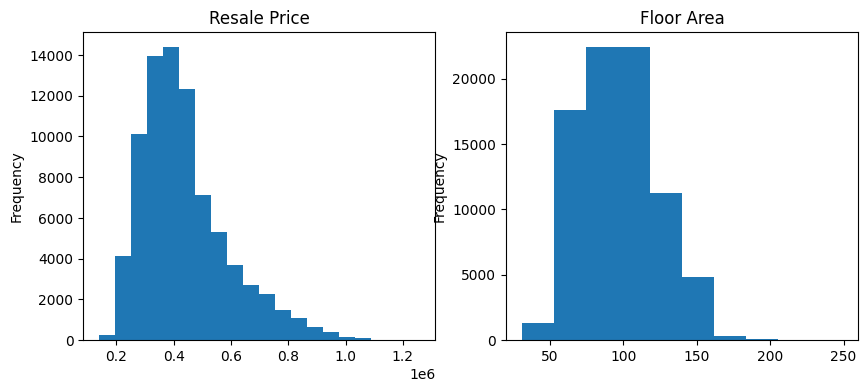

In [22]:
# Melihat visualisasi distribusi kolom building_age dan resale_price untuk menentukan teknik uji korelasi
fig, ax = plt.subplots(ncols=2,figsize=(10,4))

df['floor_area_sqm'].plot(kind='hist',ax=ax[1])
df['resale_price'].plot(kind='hist',bins=20,ax=ax[0])

ax[0].set_title('Resale Price')
ax[1].set_title('Floor Area')

- Distribusi data resale_price terlihat tidak normal (right skewness)
- Distribusi data luas area terlihat tidak normal, namun untuk memastikan distribusi ini tidak normal, dilakukan uji normalitas dengan analisis deskriptif lanjutan dengan melihat nilai mean, median, std, dan melihat nilai skewness dan kurtosis utk melihat nilai dan arah skewnya

In [23]:
# Menghitung mean, median, std, skewness, dan kurtosis kolom luas area
print('Kolom Luas Area')
print('Rata-rata Luas Area:', df['floor_area_sqm'].mean())
print('Median Luas Area:', df['floor_area_sqm'].median())
print('Standar deviasi Luas Area:', df['floor_area_sqm'].std())
print('Skewness Luas Area:', df['floor_area_sqm'].skew())
print('Kurtosis Luas Area:', df['floor_area_sqm'].kurtosis())

Kolom Luas Area
Rata-rata Luas Area: 97.62042063769272
Median Luas Area: 95.0
Standar deviasi Luas Area: 24.298659048358903
Skewness Luas Area: 0.2531086403924072
Kurtosis Luas Area: -0.15952644358440038


- Hasil analisis deskriptif terhadap nilai skewness menunjukkan skewness > 0, yang artinya data bersifat positif skewness, dan nilai kurtosis < 0 menunjukkan adanya outlier pada data
- karena data berdistribusi tidak normal, maka uji korelasi yang digunakan yaitu dengan metode uji **Spearman**

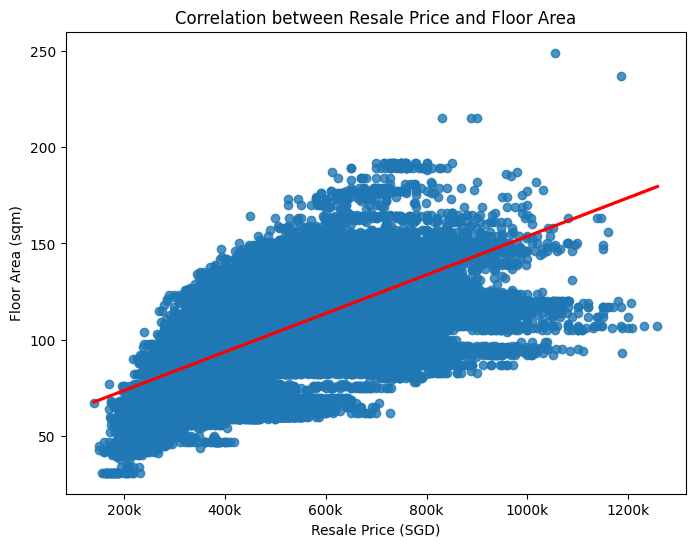

In [24]:
# Melihat korelasi antara variable harga dan luas area apartemen dengan visualisasi scatter plot
plt.figure(figsize=(8,6))
ax = sns.regplot(data=df, x='resale_price', y='floor_area_sqm',
                line_kws={'color': 'red'})

ax.xaxis.set_major_formatter(
    mtick.FuncFormatter(lambda x, _: f'{int(x/1000)}k'))

plt.xlabel('Resale Price (SGD)')
plt.ylabel('Floor Area (sqm)')
plt.title('Correlation between Resale Price and Floor Area')
plt.show()

- Hasil analisis korelasi antara harga resale dengan luas area apartemen menunjukkan korelasi bersifat positif, dimana semakin luas areanya, maka semakin tinggi harga resale apartemen tersebut
- Luas area apartemen yang kecil memiliki persebaran harga yang lebih kecil, dan luas area apartemen yang besar memiliki persebaran harga di rentang yang tinggi


In [25]:
# Menghitung korelasi antara variable harga resale dan usia bangunan dengan metode Spearman
corr_rho, pval_s = stats.spearmanr(df['resale_price'], df['floor_area_sqm'])

print(f"rho-correlation: {corr_rho:.2f}, p-value: {pval_s}")

rho-correlation: 0.70, p-value: 0.0


- Hasil analisis korelasi menunjukkan p-value < 0.5%, yang artinya luas area yang berbeda memengaruhi harga resale
- Hasil analisis korelasi dengan metode spearman menunjukkan korelasi antara harga resale dan usia bangunan memiliki korelasi positif, artinya semakin luas area apartemen, maka semakin tinggi harga resale nya, namun korelasi ini terlihat tidak terlalu nyata yang bisa disebabkan karena adanya outlier dan variable lain yang lebih berpengaruh terhadap harga

#### 6. Jika ingin mengoptimalkan penjualan apartemen dengan tipe 4 room, rentang harga berapa yang paling kompetitif di pasar saat ini?

Berdasarkan hasil analisis tipe apartemen dengan transaksi yang tinggi (no 3), apartemen dengan tipe `4 room` merupakan tipe yang memiliki total transaksi tertinggi. Dengan hasil ini, salah satu strategi penjualan yg bisa dilakukan yaitu dengan memilih apartemen dengan tipe `4 room` sebagai tipe untuk proyek penjualan apartemen selanjutnya. Sehingga, dilakukan analisis untuk melihat rentang harga resale apartemen dengan `4 room` menggunakan `Confidence Interval`

In [26]:
# Melakukan filter data apartemen dengan model A
tipe = '4 ROOM'
df_tipe = df[df['flat_type'] == tipe]

Karena distribusi harga (`resale_price`) bersifat tidak normal (right skewness), maka analisis confidence interval dilakukan dengan menggunakan median nilai resale_price

In [27]:
# Menghitung nilai Confidence Interval
median = df_tipe['resale_price'].median()
IQR = df_tipe['resale_price'].quantile(0.75) - df['resale_price'].quantile(0.25)
N = len(df_tipe['resale_price'])

upper = median + 1.7 * (1.25 * IQR / (1.35 * np.sqrt(N)))
lower = median - 1.7 * (1.25 * IQR / (1.35 * np.sqrt(N)))

print('Lower limit:', lower)
print('Upper limit:', upper)

Lower limit: 403789.75823530933
Upper limit: 406210.24176469067


In [28]:
# Melihat proporsi confidence interval
ci2 = upper - lower
proporsi2 = ci2 / df_tipe['resale_price'].median()

print('Confidence Interval:',proporsi2)

Confidence Interval: 0.005976502541682315


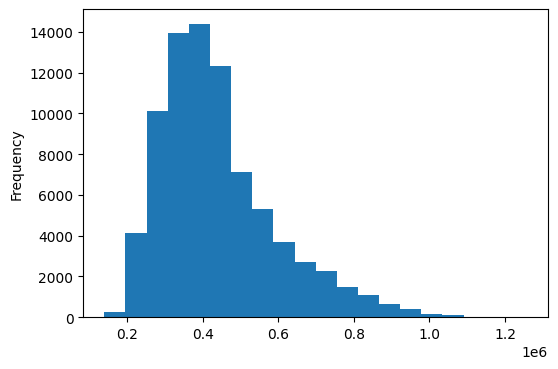

In [29]:
# Melihat visualisasi distribusi kolom resale_price
plt.figure(figsize=(6,4))
df['resale_price'].plot(kind='hist', bins=20)
plt.show()


- Hasil perhitungan Confidence Interval menunjukkan rentang harga penjualan apartemen dengan tipe 4 room di pasar saat ini yaitu 403.789 - 406.210 SGD
- Confidence Interval tergolong sempit (0.60%), yang artinya sample nya besar dan data variasi data nya kecil

# Pengambilan Kesimpulan

- Dalam kurun waktu 4 tahun (2017 - 2020), harga rata-rata resale apartemen mengalami penurunan pada tahun 2019, dan meningkat dengan signifikan di tahun 2020, hal ini berbanding terbalik pada total transaksinya, dimana total transaksi mengalami puncak tertinggi pada tahun 2019, dan mengalami penurunan di tahun 2020
- Wilayah yang berkontribusi terbesar pada pengaruh harga rata-rata resale tiap tahunnya yaitu Bukit Timah, dan wilayah yang berkontribusi terbesar dalam total transaksi tiap tahunnya yaitu wilayah Sengkang
- Apartemen dengan tipe `4 room` merupakan tipe apartemen dengan tingkat volume transaksi tertinggi. Hal ini berarti pemilihan apartemen dengan tipe `4 room` merupakan strategi penjualan yang tepat untuk dikembangkan pada top 5 wilayah dengan total transaksi tinggi yaitu wilayah Sengkang, Woodlands, Jurong West, Yishun, dan Tampines  
- Rata-rata harga resale penjualan apartemen memiliki beberapa faktor yang mempengaruhinya, seperti usia bangunan dan luas area. Dimana semakin tua usia bangunan, maka semakin kecil harga resale nya, dan semakin luas areanya maka semakin tinggi harga resale apartemen tersebut. Hal ini menandakan karakteristik apartemen berpengaruh terhadap harga resale apartemen. Untuk meningkatkan potensi penjualan apartemen, perusahaan perlu mempertimbangkan karakteristik apartemen seperti tipe, luas area, dan usia bangunan pada wilayah dengan kontribusi volume transaksi terbesar
- Strategi penjualan apartemen untuk proyek baru perusahaan dilakukan dengan mengembangkan apartemen dengan tipe 4 room di wilayah Sengkang, Woodlans, Jurong West, Yishun, dan Tampines, dengan memperhatikan karakteristik apartemen, dan rentang harga di 403.789 - 406.210 SGD agar bisa bersaing di pasar.


In [30]:
# Download hasil data cleaning untuk visualisasi dashboard
# df.to_csv('apartement_fix.csv', index=False)